# Project: Train Linear Regression

## 0. Overview

**Problem statement:** Build a linear regression model from absolute scratch — no scikit-learn, no closed-form solution — using only gradient descent on a mean squared error loss. Then verify the result against the normal equations *(ch181 — Linear Regression via Matrix Algebra)*.

**Concepts applied:**
- Gradient computation (ch209, ch210)
- Gradient-based learning (ch227)
- Matrix algebra for the closed-form solution (ch151–ch163, Part VI)
- Error and residuals (ch073)

**Expected output:** Trained weights matching the analytical solution, loss curves, residual analysis.

**Difficulty:** Intermediate. Estimated time: 45–60 min.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Environment ready.")


Environment ready.


## 1. Setup — Generate Synthetic Data

In [2]:
# True model: y = 3.5 * x1 - 2.1 * x2 + 1.8 + noise
n_samples = 200
n_features = 2

X = np.random.randn(n_samples, n_features)
true_w = np.array([3.5, -2.1])
true_b = 1.8
noise = np.random.normal(0, 0.5, n_samples)
y = X @ true_w + true_b + noise

print(f"Data shape: X={X.shape}, y={y.shape}")
print(f"True weights: {true_w}, bias: {true_b}")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")

# Train/test split
split = int(0.8 * n_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


Data shape: X=(200, 2), y=(200,)
True weights: [ 3.5 -2.1], bias: 1.8
y range: [-9.79, 13.96]


## 2. Stage 1 — Analytical Solution (Normal Equations)

The closed-form solution minimises the loss exactly:

```
w* = (X^T X)^{-1} X^T y
```

*(introduced in ch181 — Linear Regression via Matrix Algebra)*

In [3]:
# Add bias column (column of ones)
def add_bias(X): return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

# Normal equations: w = (X^T X)^{-1} X^T y
w_analytical = np.linalg.lstsq(X_train_b, y_train, rcond=None)[0]
bias_analytical, weights_analytical = w_analytical[0], w_analytical[1:]

print("=== Analytical Solution (Normal Equations) ===")
print(f"  Weights: {weights_analytical}")
print(f"  Bias:    {bias_analytical:.4f}")
print(f"  True w:  {true_w}, b: {true_b}")

def mse(y_true, y_pred): return np.mean((y_true - y_pred)**2)
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

y_pred_analytical = X_test_b @ w_analytical
print(f"\nTest MSE:  {mse(y_test, y_pred_analytical):.6f}")
print(f"Test R²:   {r2(y_test, y_pred_analytical):.6f}")


=== Analytical Solution (Normal Equations) ===
  Weights: [ 3.54856382 -2.08075043]
  Bias:    1.7428
  True w:  [ 3.5 -2.1], b: 1.8

Test MSE:  0.257961
Test R²:   0.983749


## 3. Stage 2 — Gradient Descent Implementation

In [4]:
def linear_predict(X, w, b): return X @ w + b

def mse_loss(X, y, w, b): return np.mean((linear_predict(X, w, b) - y)**2)

def mse_gradients(X, y, w, b):
    n = len(y)
    err = linear_predict(X, w, b) - y     # (n,)
    dw = (2/n) * X.T @ err                # (d,)
    db = (2/n) * np.sum(err)              # scalar
    return dw, db

def train_sgd(X_train, y_train, lr=0.05, n_epochs=500, batch_size=32):
    n, d = X_train.shape
    w = np.zeros(d)
    b = 0.0
    losses = []
    for epoch in range(n_epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start+batch_size]
            dw, db = mse_gradients(X_train[batch], y_train[batch], w, b)
            w -= lr * dw
            b -= lr * db
        losses.append(mse_loss(X_train, y_train, w, b))
    return w, b, losses

w_gd, b_gd, loss_history = train_sgd(X_train, y_train, lr=0.05, n_epochs=300, batch_size=32)

print("=== Gradient Descent Solution ===")
print(f"  Weights: {w_gd}")
print(f"  Bias:    {b_gd:.4f}")
print(f"  Final training loss: {loss_history[-1]:.6f}")

y_pred_gd = linear_predict(X_test, w_gd, b_gd)
print(f"  Test MSE: {mse(y_test, y_pred_gd):.6f}")
print(f"  Test R²:  {r2(y_test, y_pred_gd):.6f}")


=== Gradient Descent Solution ===
  Weights: [ 3.54762391 -2.08167111]
  Bias:    1.7476
  Final training loss: 0.241467
  Test MSE: 0.257242
  Test R²:  0.983794


## 4. Stage 3 — Comparison and Residual Analysis

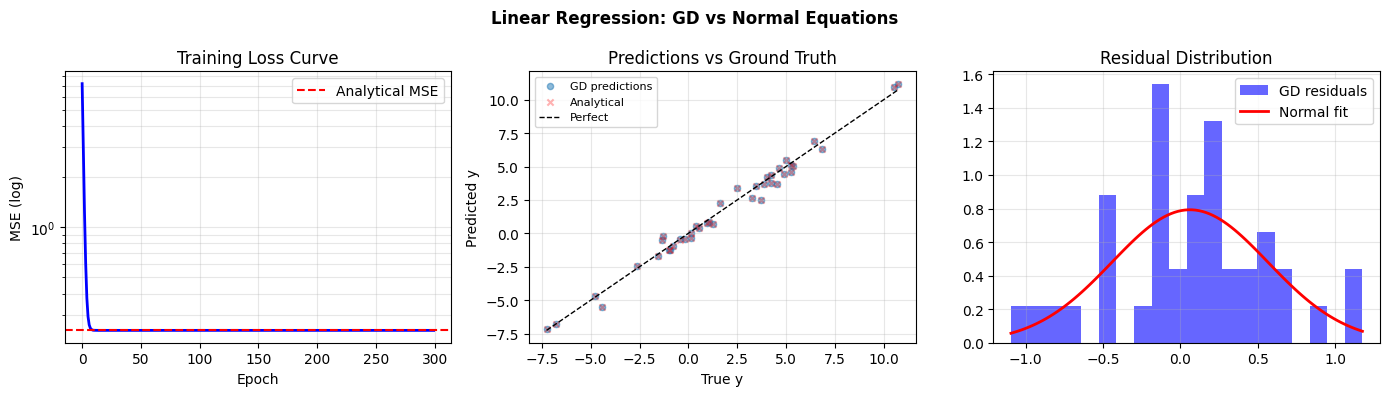


Weight comparison:
                 True   Analytical  GD (300 ep)
  w[0]         3.5000       3.5486       3.5476
  w[1]        -2.1000      -2.0808      -2.0817
  bias         1.8000       1.7428       1.7476


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss curve
axes[0].semilogy(loss_history, 'b', lw=2)
axes[0].axhline(mse(y_train, X_train_b @ w_analytical), color='red', ls='--', label='Analytical MSE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (log)')
axes[0].set_title('Training Loss Curve'); axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)

# Predictions vs truth
axes[1].scatter(y_test, y_pred_gd, alpha=0.5, s=20, label='GD predictions')
axes[1].scatter(y_test, y_pred_analytical, alpha=0.3, s=20, marker='x', color='red', label='Analytical')
lo, hi = y_test.min(), y_test.max()
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect')
axes[1].set_xlabel('True y'); axes[1].set_ylabel('Predicted y')
axes[1].set_title('Predictions vs Ground Truth'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Residuals
residuals_gd = y_test - y_pred_gd
axes[2].hist(residuals_gd, bins=20, color='blue', alpha=0.6, label='GD residuals', density=True)
x_r = np.linspace(residuals_gd.min(), residuals_gd.max(), 100)
from scipy.stats import norm
mu_r, sigma_r = norm.fit(residuals_gd)
axes[2].plot(x_r, norm.pdf(x_r, mu_r, sigma_r), 'r', lw=2, label='Normal fit')
axes[2].set_title('Residual Distribution'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Linear Regression: GD vs Normal Equations', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('ch229_linear_regression.png', dpi=100); plt.show()

# Weight comparison table
print("\nWeight comparison:")
print(f"{'':12} {'True':>8} {'Analytical':>12} {'GD (300 ep)':>12}")
for i, (t, a, g) in enumerate(zip(true_w, weights_analytical, w_gd)):
    print(f"  w[{i}]       {t:>8.4f} {a:>12.4f} {g:>12.4f}")
print(f"  bias       {true_b:>8.4f} {bias_analytical:>12.4f} {b_gd:>12.4f}")


## 5. Results & Reflection

**What was built:** A complete linear regression trainer from scratch — gradient computation, mini-batch SGD, and comparison to the analytical normal equations solution.

**What math made it possible:**
- MSE gradient: dL/dw = (2/n) X^T (Xw - y) — derived from matrix calculus *(Part VI, ch210)*
- Normal equations: (X^T X)^{-1} X^T y — the least-squares minimiser *(ch181)*
- SGD convergence guaranteed for convex loss with appropriate learning rate *(ch212, ch227)*

**Extension challenges:**
1. Add L2 regularisation (Ridge regression): modify the gradient with `+2*lambda*w` and observe how large lambda shrinks weights.
2. Implement learning rate decay (multiply lr by 0.95 every 50 epochs) and compare convergence.
3. Extend to polynomial regression by constructing X with powers [x, x^2, x^3] and observe overfitting as degree increases *(ch220 — Approximation)*.